# Regresión lineal del precio de la vivienda en EE. UU.

## Primer de regresión lineal

En estadística, la regresión lineal es un enfoque lineal para modelar la relación entre una variable dependiente escalar y y una o más variables explicativas (o variables independientes) denominadas X. El caso de una variable explicativa se denomina regresión lineal simple. Para más de una variable explicativa, el proceso se denomina regresión lineal múltiple.

Los modelos de regresión lineal a menudo se ajustan utilizando el enfoque de mínimos cuadrados, pero también pueden ajustarse de otras formas, como minimizando la "falta de ajuste" en alguna otra norma (como con la regresión de desviaciones mínimas absolutas), o minimizando una penalización. versión de la función de pérdida por mínimos cuadrados como en la regresión de crestas (penalización de $L_2$ -norm) y lazo (penalización de $L_1$ -norm). Por el contrario, el enfoque de mínimos cuadrados se puede utilizar para ajustar modelos que no son modelos lineales. Por lo tanto, aunque los términos "mínimos cuadrados" y "modelo lineal" están estrechamente relacionados, no son sinónimos.

### Importando paquetes y el conjunto de datos

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [ ]:
#df = pd.read_csv("https://github.com/ulewis/Ejemplos/raw/main/Datos/USA_Housing.csv")
df = pd.read_csv("https://github.com/ulewis/Ejemplos/raw/main/Datos/healthcare_dataset.csv")

df.head(100)  # vemos los 5 primeros datos del dataframe

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Tiffany Ramirez,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,37490.983364,146,Elective,2022-12-01,Aspirin,Inconclusive
1,Ruben Burns,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,47304.064845,404,Emergency,2023-06-15,Lipitor,Normal
2,Chad Byrd,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton LLC,Medicare,36874.896997,292,Emergency,2019-02-08,Lipitor,Normal
3,Antonio Frederick,49,Male,B-,Asthma,2020-05-02,Brian Chandler,Garcia Ltd,Medicare,23303.322092,480,Urgent,2020-05-03,Penicillin,Abnormal
4,Mrs. Brandy Flowers,51,Male,O-,Arthritis,2021-07-09,Dustin Griffin,"Jones, Brown and Murray",UnitedHealthcare,18086.344184,477,Urgent,2021-08-02,Paracetamol,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Samuel Welch,44,Male,B-,Hypertension,2020-02-26,Stacy Salazar,Barnett-Davis,Cigna,22577.602608,119,Elective,2020-03-18,Aspirin,Abnormal
96,Steven Boyer,38,Male,B+,Arthritis,2020-12-10,Mitchell Bradshaw,Holmes-Cummings,Medicare,11057.975641,176,Emergency,2021-01-09,Ibuprofen,Abnormal
97,Gabrielle Francis,81,Male,A-,Asthma,2022-10-15,Jennifer Barry,Gilbert-Moody,Blue Cross,1923.906794,462,Elective,2022-10-19,Ibuprofen,Abnormal
98,Christian Guerrero,20,Male,B+,Cancer,2023-07-03,Catherine Russell,"Berry, Stone and Wood",Blue Cross,33776.799588,484,Urgent,2023-07-19,Aspirin,Inconclusive


--- Resultados del Modelo ---
R^2 (Coeficiente de Determinación): 0.0015
Error Absoluto Medio (MAE): $12250.73
---------------------------



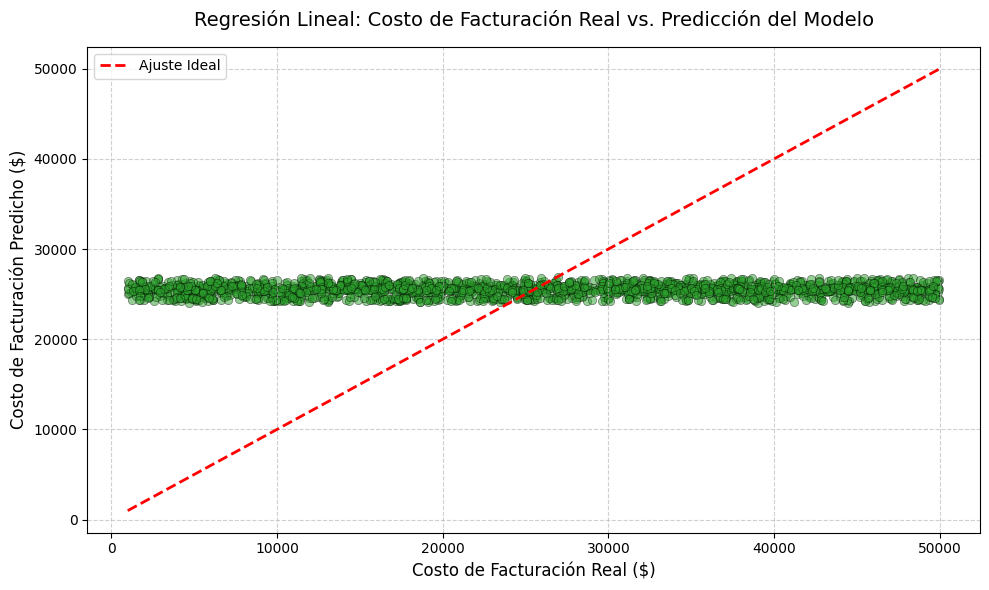

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Carga del conjunto de datos
# REEMPLAZA "healthcare_dataset.csv" por el nombre exacto de tu archivo o su ruta completa
ruta_archivo = "https://github.com/ulewis/Ejemplos/raw/main/Datos/healthcare_dataset.csv"
df = pd.read_csv(ruta_archivo)

# 2. Selección de variables
# Usaremos la Edad como variable numérica y las demás como categóricas para predecir la Facturación.
features = ['Age', 'Gender', 'Medical Condition', 'Admission Type']
X = df[features]
y = df['Billing Amount'] # Variable objetivo a predecir

# 3. Transformación de categorías: One-Hot Encoding
# Convertimos las columnas de texto en columnas numéricas de 0s y 1s.
# drop_first=True evita la trampa de la multicolinealidad.
X_encoded = pd.get_dummies(X, columns=['Gender', 'Medical Condition', 'Admission Type'], drop_first=True)

# 4. División de los datos en Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 5. Inicialización y entrenamiento del Modelo de Regresión Lineal
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# 6. Realizar predicciones con el conjunto de prueba
y_pred = modelo.predict(X_test)

# 7. Evaluación rápida del modelo
print("--- Resultados del Modelo ---")
print(f"R^2 (Coeficiente de Determinación): {r2_score(y_test, y_pred):.4f}")
print(f"Error Absoluto Medio (MAE): ${mean_absolute_error(y_test, y_pred):.2f}")
print("---------------------------\n")

# 8. Representación Gráfica (Regresión Lineal: Real vs Predicho)
plt.figure(figsize=(10, 6))

# Gráfico de dispersión de los datos
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='#2ca02c', edgecolor='black')

# Línea de referencia (Predicción perfecta)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ajuste Ideal')

# Estética del gráfico
plt.title('Regresión Lineal: Costo de Facturación Real vs. Predicción del Modelo', fontsize=14, pad=15)
plt.xlabel('Costo de Facturación Real ($)', fontsize=12)
plt.ylabel('Costo de Facturación Predicho ($)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Renderizar gráfico
plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:         Billing Amount   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     2.525
Date:                Tue, 14 Apr 2026   Prob (F-statistic):            0.00689
Time:                        17:31:52   Log-Likelihood:            -1.0969e+05
No. Observations:               10000   AIC:                         2.194e+05
Df Residuals:                    9990   BIC:                         2.195e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

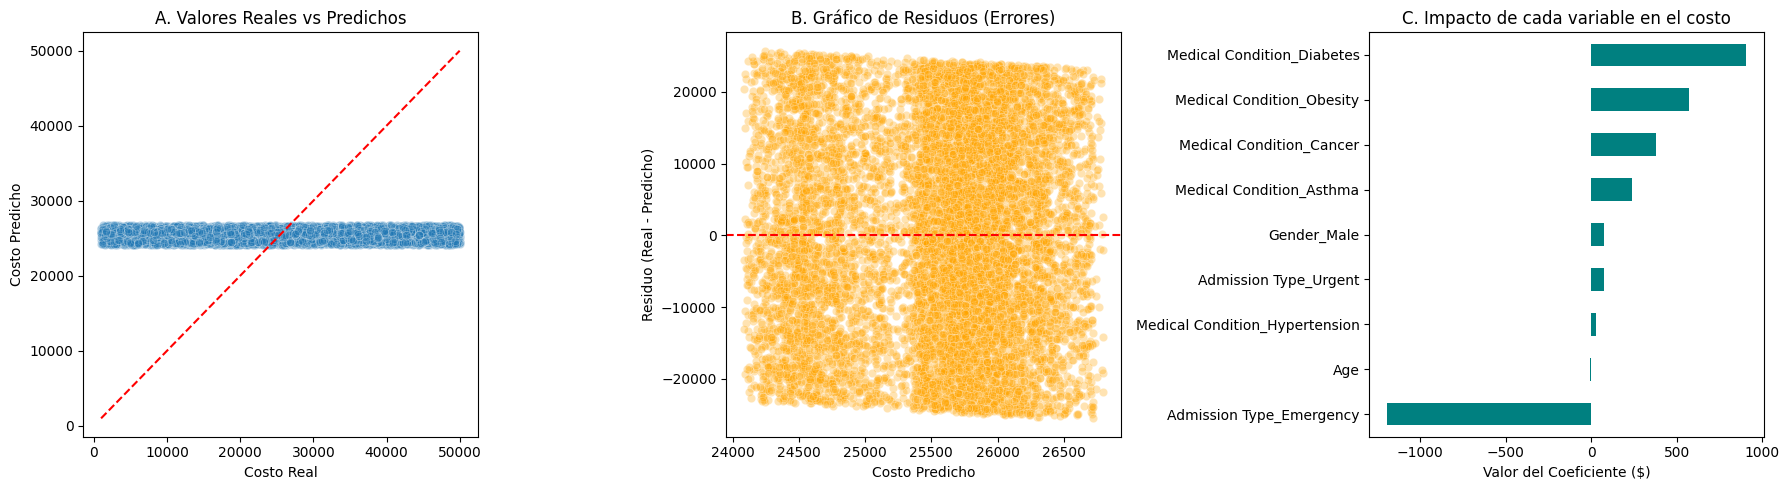

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm # Importamos statsmodels para OLS

# 1. Cargar datos y preparar variables (igual que antes)
# df = pd.read_csv("healthcare_dataset.csv") # Original line causing error
df = pd.read_csv("https://github.com/ulewis/Ejemplos/raw/main/Datos/healthcare_dataset.csv") # Fixed line
features = ['Age', 'Gender', 'Medical Condition', 'Admission Type']
X = df[features]
y = df['Billing Amount']

# 2. One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=['Gender', 'Medical Condition', 'Admission Type'], drop_first=True)

# --- FIX: Convert boolean columns to numeric type for statsmodels ---
X_encoded = X_encoded.astype(float)
# -------------------------------------------------------------------

# 3. Preparación para OLS (¡Paso Crucial!)
# statsmodels requiere que añadamos explícitamente una constante (el intercepto o punto de cruce en el eje Y)
X_ols = sm.add_constant(X_encoded)

# 4. Creación y ajuste del modelo OLS
modelo_ols = sm.OLS(y, X_ols).fit()

# Mostrar el resumen estadístico completo (te dará el R-squared, P-values, etc.)
print(modelo_ols.summary())

# Generar predicciones
y_pred = modelo_ols.predict(X_ols)
residuos = y - y_pred # Calculamos el error de cada predicción

# --- 5. OPCIONES DE GRÁFICOS AVANZADOS ---

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico A: Real vs Predicho (El que ya conoces)
sns.scatterplot(x=y, y=y_pred, alpha=0.3, ax=axes[0])
min_val, max_val = y.min(), y.max()
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
axes[0].set_title('A. Valores Reales vs Predichos')
axes[0].set_xlabel('Costo Real')
axes[0].set_ylabel('Costo Predicho')

# Gráfico B: Gráfico de Residuos (Errores)
# Ayuda a ver si los errores tienen algún patrón. Deberían verse como una nube aleatoria.
sns.scatterplot(x=y_pred, y=residuos, alpha=0.3, color='orange', ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--') # Línea de error cero
axes[1].set_title('B. Gráfico de Residuos (Errores)')
axes[1].set_xlabel('Costo Predicho')
axes[1].set_ylabel('Residuo (Real - Predicho)')

# Gráfico C: Importancia de las variables (Coeficientes)
# Eliminamos la 'const' para ver solo las variables
coeficientes = modelo_ols.params.drop('const')
coeficientes.sort_values().plot(kind='barh', ax=axes[2], color='teal')
axes[2].set_title('C. Impacto de cada variable en el costo')
axes[2].set_xlabel('Valor del Coeficiente ($)')

plt.tight_layout()
plt.show()

# Descripcion de los graficos



1. Gráfico de Valores Reales vs. Predichos

Como los precios en tu archivo están al azar y no tienen relación real con la enfermedad o la edad del paciente, al ejecutar el modelo de código no encontró ninguna relación apropiada, con lo que decidió predecir casi siempre el mismo costo promedio para todos. Por eso los puntos forman una mancha vertical en el medio en lugar de una línea diagonal perfecta.


2. Gráfico de Residuos (Errores)

Este cuadro muestra. Al predecir siempre ese mismo costo promedio, a veces el paciente real terminó pagando muchísimo más o muchísimo menos. Esa gran nube desordenada de puntos puede confirmar visualmente que el modelo está tratando de adivinar a ciegas y sus errores son totalmente aleatorios.


3. Gráfico de Coeficientes

Las barras que indican cuánto dinero supuestamente suma o resta ser de cierto género o tener cierta condición médica. Sin embargo, como sabemos que los datos son aleatorios y el modelo no fue el correcto, estas barras no ayudan mucho. Son puro ruido estadístico y casualidad; si fueran otros datos al azar, las barras apuntarían hacia lados completamente distintos.



